# Network I/O Simulation: How Latency and Message Loss Affect Market Making

This notebook demonstrates how network impairments affect market making performance using the `NetworkIO` class integrated into `OrderBookSimulator`.

## Why Network I/O Matters for Market Making

In real HFT systems, the market maker communicates with the exchange over a network:
- **Inbound**: receive market data (order book updates, trades)
- **Outbound**: send quotes (buy/sell orders), cancel orders

Network impairments create a feedback loop that degrades the MM's performance:

```
Latency → MM sees stale prices → computes wrong quotes → gets filled at bad prices
Message loss → MM's quotes never arrive → zero fills → missed revenue
Disconnection → MM goes dark → no quotes, no fills → inventory drifts unmanaged
```

### The Three Network Effects

| Effect | What happens | Why it matters for MM |
|--------|-------------|---------------------|
| **Latency** | Data from exchange arrives N steps late. MM computes quotes based on old mid price. | If the true mid has moved, the MM's buy/sell quotes are off-market. In extreme cases, quotes become *crossed* (buy price ≥ sell price) — which would be immediately arbitraged. |
| **Message loss** | The MM's outgoing quote is dropped and never reaches the exchange. | No fill possible that step. This is pure opportunity cost — the spread the MM could have earned is lost. |
| **Disconnection** | The network drops entirely for N steps. No data in, no quotes out. | The MM is blind and paralyzed. If it holds inventory, the price can move against it with no way to hedge. This is the most dangerous impairment. |

### How the Simulator Models Each Effect

- **Latency**: The simulator maintains a `_price_buffer` of historical mid prices. When latency = N steps, the MM sees the mid price from N steps ago and computes quotes from that stale price. This means the MM's buy/sell quotes may not match the current market.
- **Message loss**: A per-step probability that the MM's quote is simply discarded. No fills occur that step.
- **Disconnection**: A rare event that takes the MM offline for `reconnect_duration` steps. During disconnection, no quotes are posted and no fills occur.
- **Slow path**: Occasional latency spikes (modeling GC pauses, TCP retransmits, kernel scheduling). These are drawn from an exponential distribution with a long tail.

In [1]:
import sys
sys.path.insert(0, '.')

from simulator import OrderBookSimulator, NetworkIO
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100

## 1. NetworkIO in Isolation

First, let's see the raw network behavior before plugging it into the market simulator.

### NetworkIO Parameters Explained

| Parameter | Meaning | Typical Real-World Analog |
|-----------|---------|--------------------------|
| `base_latency_steps` | Median one-way latency | Fiber distance to exchange (e.g., 1 step ≈ 1μs for co-located, ≈ 1ms for cross-region) |
| `jitter_steps` | Std dev of latency variation | OS scheduling jitter, NIC buffer variability |
| `slow_path_prob` | Chance of a latency spike per step | GC pause, TCP retransmit, page fault |
| `slow_path_latency` | Mean latency during a slow path event | Typically 5–50× normal latency |
| `message_loss_prob` | Chance an outgoing message is lost | UDP drop, hardware error, buffer overflow |
| `reconnect_prob` | Chance of disconnection per step | Network switch failover, ISP outage |
| `reconnect_duration` | Steps to reconnect | Time for TCP handshake + login + state recovery |

In [2]:
net = NetworkIO(
    base_latency_steps=1.0,
    jitter_steps=0.5,
    slow_path_prob=0.03,
    slow_path_latency=8.0,
    message_loss_prob=0.02,
    reconnect_prob=0.002,
    reconnect_duration=15,
    seed=42,
)

for _ in range(1000):
    net.step()

print(f"Average latency:     {net.avg_latency:.2f} steps")
print(f"Message loss rate:   {net.loss_rate*100:.2f}%")
print(f"Uptime:              {net.uptime_pct:.1f}%")
print(f"Total reconnects:    {net.total_reconnects}")
print(f"Total messages lost: {net.total_messages_lost}")
print(f"Total slow-path events: {sum(1 for e in net.events if e.event_type == 'latency')}")

Average latency:     1.12 steps
Message loss rate:   1.70%
Uptime:              95.5%
Total reconnects:    3
Total messages lost: 17
Total slow-path events: 17


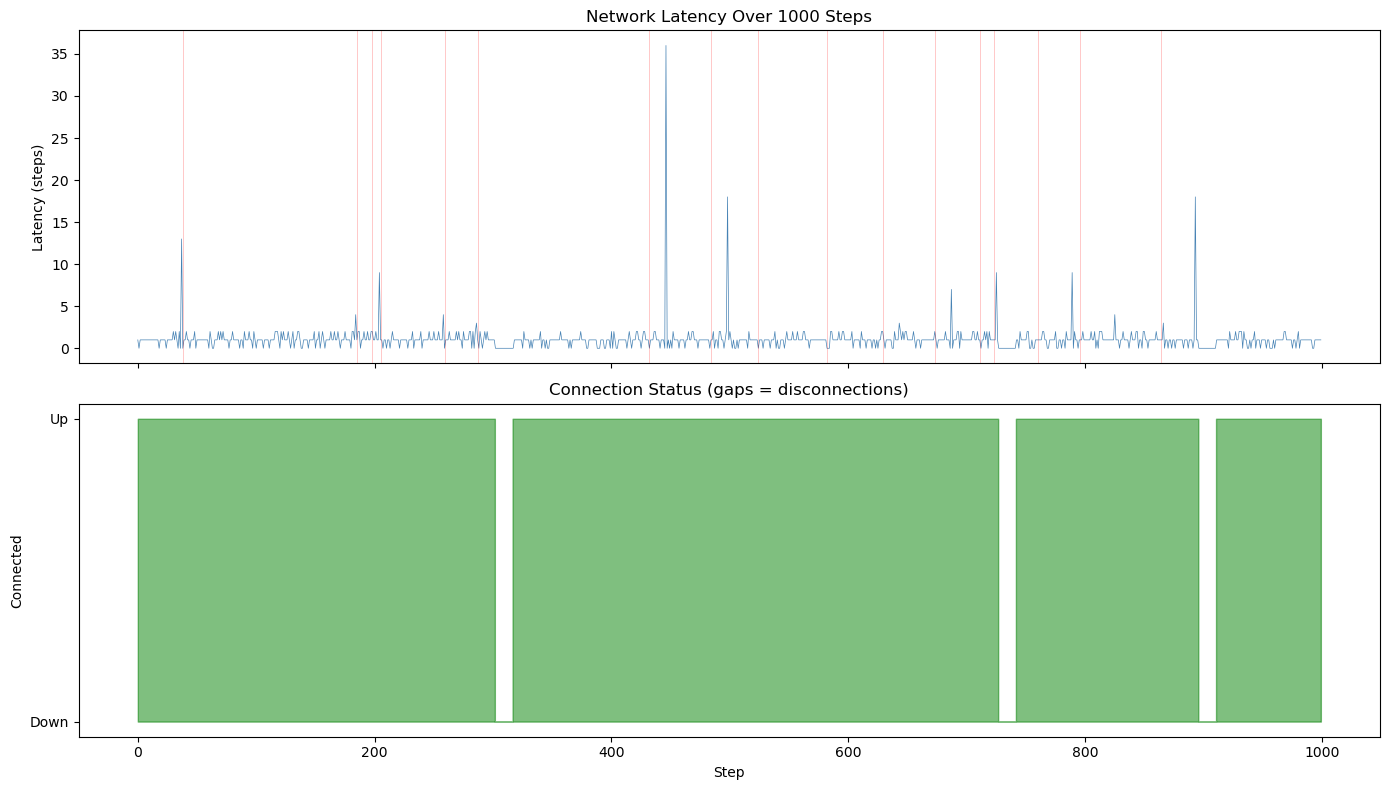

In [3]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

latency = net.latency_history
connected = net.connected_history

# Latency plot
ax1.plot(latency, linewidth=0.5, color='steelblue')
ax1.set_ylabel('Latency (steps)')
ax1.set_title('Network Latency Over 1000 Steps')

# Mark slow-path events
for e in net.events:
    if e.event_type == 'latency':
        ax1.axvline(e.timestamp, color='red', alpha=0.3, linewidth=0.5)

# Connection status
ax2.fill_between(range(len(connected)), connected, step='mid', alpha=0.5, color='green')
ax2.set_ylabel('Connected')
ax2.set_xlabel('Step')
ax2.set_title('Connection Status (gaps = disconnections)')
ax2.set_yticks([0, 1])
ax2.set_yticklabels(['Down', 'Up'])

plt.tight_layout()
plt.show()

## 2. Latency Distribution

Latency follows a **mixture distribution**: most of the time the MM is on a fast path (low, tight latency), but occasionally a slow-path event (GC pause, TCP retransmit) causes a large spike.

This creates a **bimodal** or **heavy-tailed** distribution:
- The **median** is close to `base_latency_steps` (fast path)
- The **mean** is pulled higher by the slow-path tail
- The gap between mean and median reveals how often slow paths occur

In real HFT systems, this distribution is critical: most trades happen on the fast path, but a single slow-path event during a volatile market can cause significant losses.

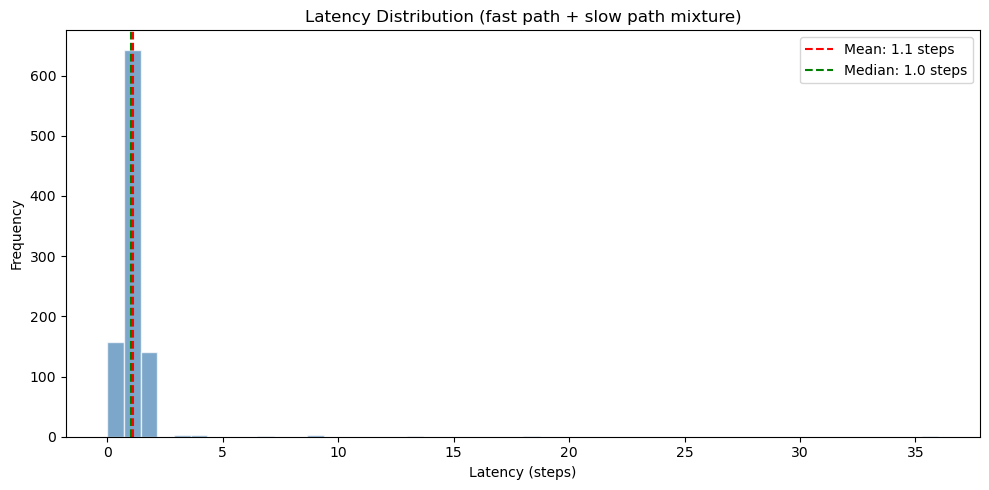

In [4]:
active_latency = [l for l, c in zip(net.latency_history, net.connected_history) if c]

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(active_latency, bins=50, color='steelblue', alpha=0.7, edgecolor='white')
ax.axvline(np.mean(active_latency), color='red', linestyle='--', label=f'Mean: {np.mean(active_latency):.1f} steps')
ax.axvline(np.median(active_latency), color='green', linestyle='--', label=f'Median: {np.median(active_latency):.1f} steps')
ax.set_xlabel('Latency (steps)')
ax.set_ylabel('Frequency')
ax.set_title('Latency Distribution (fast path + slow path mixture)')
ax.legend()

plt.tight_layout()
plt.show()

## 3. Market Making With vs Without Network Effects

Now let's compare the same market maker with and without network I/O.

### Why Network Effects Reduce P&L

1. **Stale quotes**: With latency, the MM's buy/sell prices are computed from an old mid price. If the true mid has drifted, the MM posts quotes that are too high or too low — effectively giving away edge to the counterparty.
2. **Missed fills**: With message loss and disconnection, the MM simply doesn't get some fills. Each missed fill is lost spread revenue.
3. **Inventory drift**: Disconnections are especially harmful because the MM holds inventory but can't manage it. If price moves against the position while offline, the mark-to-market loss compounds.
4. **Compounding with adverse selection**: When the MM *does* get a fill on stale data, it's more likely to be from an informed trader who sees the MM's off-market quote — the worst possible counterparty.

In [5]:
N_STEPS = 10000

# Without network
sim_ideal = OrderBookSimulator(
    initial_mid=100.0, base_spread_bps=5.0, volatility=0.02,
    fill_rate=0.15, adverse_selection_bps=0.5, seed=42,
)
sim_ideal.run(n_steps=N_STEPS, inside_pct=0.2, mm_qty=50)
df_ideal = sim_ideal.get_snapshot_dataframe()

# With network (moderate latency)
net_mod = NetworkIO(
    base_latency_steps=1.0, jitter_steps=0.5,
    slow_path_prob=0.03, slow_path_latency=8.0,
    message_loss_prob=0.02, reconnect_prob=0.002,
    reconnect_duration=15, seed=42,
)
sim_net = OrderBookSimulator(
    initial_mid=100.0, base_spread_bps=5.0, volatility=0.02,
    fill_rate=0.15, adverse_selection_bps=0.5, network=net_mod, seed=42,
)
sim_net.run(n_steps=N_STEPS, inside_pct=0.2, mm_qty=50)
df_net = sim_net.get_snapshot_dataframe()

print("=== Without Network ===")
print(f"  P&L: ${sim_ideal.mark_to_market_pnl:.2f}, Fills: {len(sim_ideal.fills)}, Inventory: {sim_ideal.inventory}")
print("\n=== With Network (moderate) ===")
print(f"  P&L: ${sim_net.mark_to_market_pnl:.2f}, Fills: {len(sim_net.fills)}, Inventory: {sim_net.inventory}")
print(f"  Avg latency: {net_mod.avg_latency:.1f} steps, Loss: {net_mod.loss_rate*100:.1f}%, Uptime: {net_mod.uptime_pct:.1f}%")

=== Without Network ===
  P&L: $1174.52, Fills: 1801, Inventory: 1950

=== With Network (moderate) ===
  P&L: $668.91, Fills: 1737, Inventory: 2650
  Avg latency: 1.2 steps, Loss: 1.9%, Uptime: 97.0%


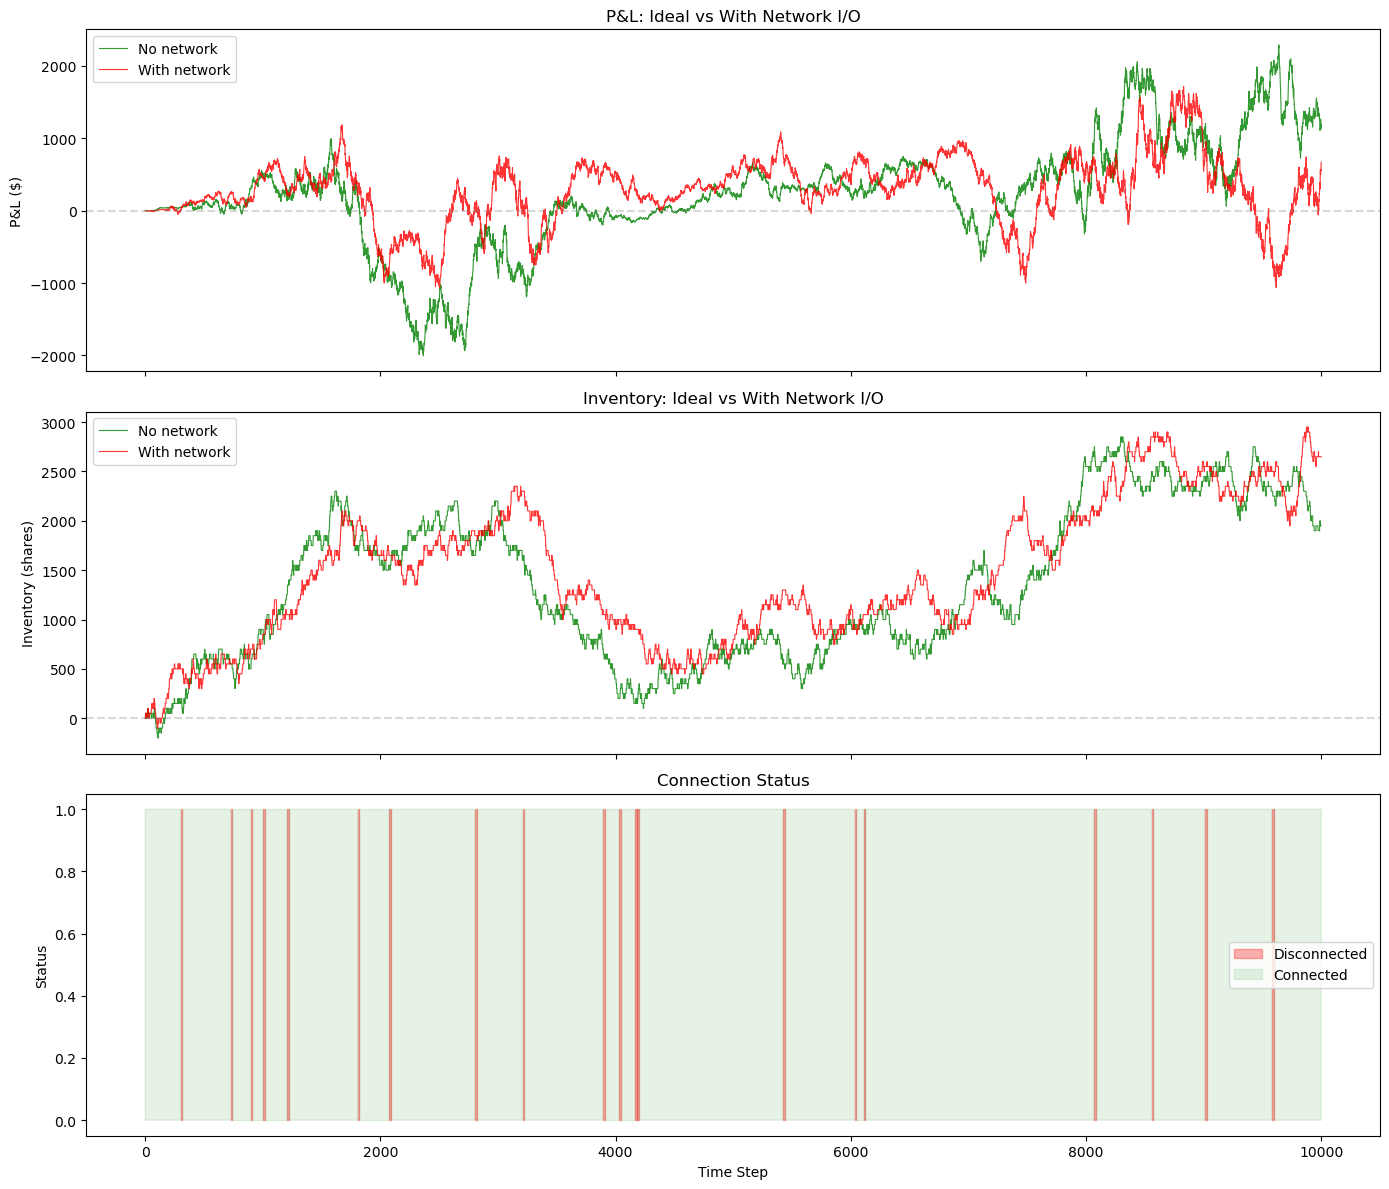

In [6]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

ax1.plot(df_ideal['time'], df_ideal['pnl'], linewidth=0.8, color='green', label='No network', alpha=0.8)
ax1.plot(df_net['time'], df_net['pnl'], linewidth=0.8, color='red', label='With network', alpha=0.8)
ax1.axhline(0, color='gray', linestyle='--', alpha=0.3)
ax1.set_ylabel('P&L ($)')
ax1.set_title('P&L: Ideal vs With Network I/O')
ax1.legend()

ax2.plot(df_ideal['time'], df_ideal['inventory'], linewidth=0.8, color='green', label='No network', alpha=0.8)
ax2.plot(df_net['time'], df_net['inventory'], linewidth=0.8, color='red', label='With network', alpha=0.8)
ax2.axhline(0, color='gray', linestyle='--', alpha=0.3)
ax2.set_ylabel('Inventory (shares)')
ax2.set_title('Inventory: Ideal vs With Network I/O')
ax2.legend()

# Mark disconnection periods
if 'connected' in df_net.columns:
    discon = df_net['connected'] == False
    ax3.fill_between(df_net['time'], 0, 1, where=discon, color='red', alpha=0.3, step='mid', label='Disconnected')
    ax3.fill_between(df_net['time'], 0, 1, where=~discon, color='green', alpha=0.1, step='mid', label='Connected')
ax3.set_ylabel('Status')
ax3.set_xlabel('Time Step')
ax3.set_title('Connection Status')
ax3.legend()

plt.tight_layout()
plt.show()

## 4. Impact of Different Latency Levels

How does increasing baseline latency affect P&L and inventory?

### The Latency–P&L Relationship

Higher latency means the MM is increasingly **out of sync** with the market:
- With **0 latency**: MM sees current prices, quotes are accurate
- With **1-step latency**: MM is one step behind; quotes slightly off during volatile periods
- With **5-step latency**: MM is significantly behind; quotes frequently wrong, fills at bad prices

The P&L degradation is **non-linear**: going from 0→1 step latency hurts less than 1→5 steps, because at higher latency the MM is systematically on the wrong side of the market.

Inventory also tends to be more imbalanced with higher latency, because the MM's quotes are asymmetrically wrong (e.g., buying too high when the market has already dropped).

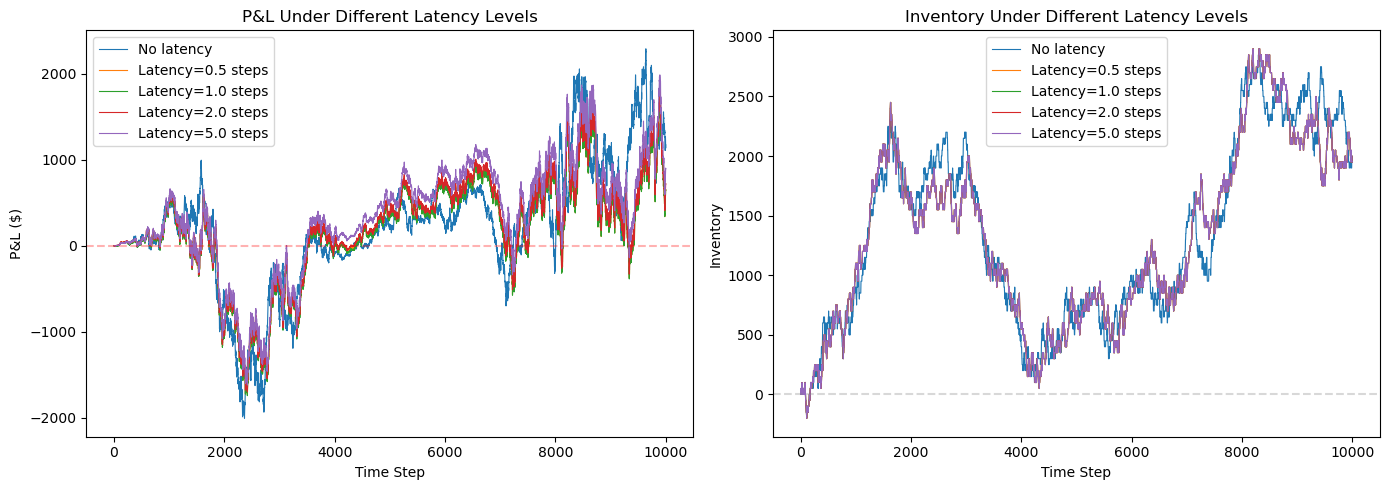

In [7]:
latency_levels = [0.0, 0.5, 1.0, 2.0, 5.0]
N_STEPS = 10000

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for base_lat in latency_levels:
    if base_lat == 0.0:
        sim = OrderBookSimulator(
            initial_mid=100.0, base_spread_bps=5.0, volatility=0.02,
            fill_rate=0.15, adverse_selection_bps=0.5, seed=42,
        )
        label = 'No latency'
    else:
        net = NetworkIO(
            base_latency_steps=base_lat, jitter_steps=base_lat * 0.3,
            slow_path_prob=0.02, slow_path_latency=base_lat * 5,
            message_loss_prob=0.01, reconnect_prob=0.001,
            reconnect_duration=10, seed=42,
        )
        sim = OrderBookSimulator(
            initial_mid=100.0, base_spread_bps=5.0, volatility=0.02,
            fill_rate=0.15, adverse_selection_bps=0.5, network=net, seed=42,
        )
        label = f'Latency={base_lat} steps'
    
    sim.run(n_steps=N_STEPS, inside_pct=0.2, mm_qty=50)
    df = sim.get_snapshot_dataframe()
    
    ax1.plot(df['time'], df['pnl'], linewidth=0.8, label=label)
    ax2.plot(df['time'], df['inventory'], linewidth=0.8, label=label)

ax1.axhline(0, color='red', linestyle='--', alpha=0.3)
ax1.set_xlabel('Time Step')
ax1.set_ylabel('P&L ($)')
ax1.set_title('P&L Under Different Latency Levels')
ax1.legend()

ax2.axhline(0, color='gray', linestyle='--', alpha=0.3)
ax2.set_xlabel('Time Step')
ax2.set_ylabel('Inventory')
ax2.set_title('Inventory Under Different Latency Levels')
ax2.legend()

plt.tight_layout()
plt.show()

## 5. Impact of Message Loss Rate

Message loss is simpler than latency — each lost quote is a straightforward **opportunity cost**.

### How Message Loss Reduces Revenue

If the MM loses `p` fraction of outgoing quotes:
- Fill count drops by roughly `p` (fewer quotes reaching the exchange = fewer fills)
- Revenue per fill is unchanged (the fills that do happen are at the same prices)
- **Total P&L drops proportionally** to the loss rate

This is why message loss is less damaging *per event* than latency — latency causes the MM to trade at wrong prices (negative edge), while message loss just means the MM misses a trade (zero edge). Zero edge is better than negative edge.

However, high message loss rates (>5%) are catastrophic because the MM simply can't maintain enough order flow to earn the spread.

In [8]:
loss_rates = [0.0, 0.01, 0.03, 0.05, 0.10]
N_STEPS = 10000

results = []
for loss_prob in loss_rates:
    if loss_prob == 0.0:
        sim = OrderBookSimulator(
            initial_mid=100.0, base_spread_bps=5.0, volatility=0.02,
            fill_rate=0.15, adverse_selection_bps=0.5, seed=42,
        )
    else:
        net = NetworkIO(
            base_latency_steps=1.0, jitter_steps=0.3,
            message_loss_prob=loss_prob, seed=42,
        )
        sim = OrderBookSimulator(
            initial_mid=100.0, base_spread_bps=5.0, volatility=0.02,
            fill_rate=0.15, adverse_selection_bps=0.5, network=net, seed=42,
        )
    
    sim.run(n_steps=N_STEPS, inside_pct=0.2, mm_qty=50)
    results.append({
        'loss_rate': loss_prob,
        'pnl': sim.mark_to_market_pnl,
        'fills': len(sim.fills),
        'inventory': sim.inventory,
    })

print(f"{'Loss Rate':>10} {'P&L':>10} {'Fills':>8} {'Inventory':>10}")
print('-' * 42)
for r in results:
    print(f"{r['loss_rate']*100:>9.1f}% ${r['pnl']:>9.2f} {r['fills']:>8d} {r['inventory']:>10d}")

 Loss Rate        P&L    Fills  Inventory
------------------------------------------
      0.0% $  1174.52     1801       1950
      1.0% $    37.14     1763       2450
      3.0% $  4278.98     1735       1950
      5.0% $   688.88     1730       1300
     10.0% $  4666.96     1605       3050


## 6. Stale Quotes: When Latency Makes You Trade at Wrong Prices

With latency, the MM computes quotes based on a stale mid price. If the true mid has moved, the MM's quotes can be significantly off — potentially even **crossed** (buy ≥ sell).

### What is a Crossed Quote?

A crossed quote occurs when the MM's buy price ≥ sell price. Example:

```
MM sees stale mid = 100.00 (latency = 5 steps)
  → buy quote = 100.005, sell quote = 100.045

But true mid has risen to 100.10
  → MM's buy quote (100.005) is BELOW the true bid (100.075)
  → MM's sell quote (100.045) is BELOW the true ask (100.125)
  → Someone buys from MM's sell at 100.045 (below true ask!)
  → MM loses money immediately
```

In extreme cases, the stale mid is so far off that the buy quote exceeds the sell quote — a **crossed market**. In real exchanges, crossed quotes are either rejected or immediately filled by arbitrageurs.

### Why This Matters

Crossed quotes represent the worst case: the MM is giving away free money. Even without crossing, stale quotes mean the MM is systematically providing liquidity at the wrong prices — effectively subsidizing informed traders.

In [9]:
net_high = NetworkIO(
    base_latency_steps=3.0, jitter_steps=1.0,
    slow_path_prob=0.05, slow_path_latency=15.0,
    message_loss_prob=0.01, reconnect_prob=0.001,
    reconnect_duration=20, seed=42,
)
sim = OrderBookSimulator(
    initial_mid=100.0, base_spread_bps=5.0, volatility=0.05,
    fill_rate=0.15, adverse_selection_bps=0.5, network=net_high, seed=42,
)

n_crossed = 0
n_stale = 0
for _ in range(10000):
    result = sim.step(inside_pct=0.2, mm_qty=50)
    if result['stale_data']:
        n_stale += 1
        if result['mm_buy_price'] >= result['mm_sell_price']:
            n_crossed += 1

print(f"Steps with stale data: {n_stale}")
print(f"Steps with crossed quotes (buy >= sell): {n_crossed}")
print(f"Crossed quote rate: {n_crossed/10000*100:.2f}%")
print(f"\nFinal P&L: ${sim.mark_to_market_pnl:.2f}, Fills: {len(sim.fills)}")

Steps with stale data: 9946
Steps with crossed quotes (buy >= sell): 0
Crossed quote rate: 0.00%

Final P&L: $2897.23, Fills: 1742


## 7. Monte Carlo: P&L Distribution With Network Effects

Running many simulations with different random seeds reveals the **distribution** of outcomes.

### What the Distribution Tells Us

- **Mean P&L shift**: Network effects push the mean P&L lower (worse expected outcome)
- **Variance increase**: Network effects add another source of randomness, widening the P&L distribution
- **Tail risk**: With high latency, the left tail (worst outcomes) gets heavier — there's a higher chance of large losses

A real HFT firm would use this analysis to determine whether their strategy is viable given their network infrastructure. If the left tail overlaps zero too much, the strategy is not worth the risk.

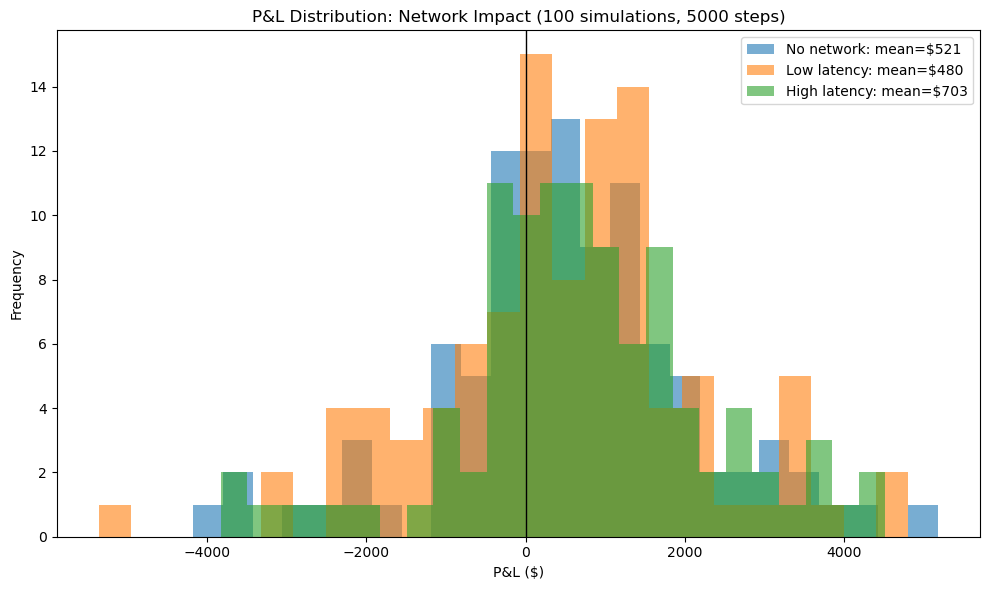

In [10]:
N_SIMS = 100
N_STEPS = 5000

pnl_no_net = []
pnl_low_lat = []
pnl_high_lat = []

for i in range(N_SIMS):
    # No network
    s0 = OrderBookSimulator(
        initial_mid=100.0, base_spread_bps=5.0, volatility=0.02,
        fill_rate=0.15, adverse_selection_bps=0.5, seed=i,
    )
    s0.run(n_steps=N_STEPS, inside_pct=0.2, mm_qty=50)
    pnl_no_net.append(s0.mark_to_market_pnl)
    
    # Low latency
    net1 = NetworkIO(base_latency_steps=0.5, jitter_steps=0.2, message_loss_prob=0.005, seed=i)
    s1 = OrderBookSimulator(
        initial_mid=100.0, base_spread_bps=5.0, volatility=0.02,
        fill_rate=0.15, adverse_selection_bps=0.5, network=net1, seed=i,
    )
    s1.run(n_steps=N_STEPS, inside_pct=0.2, mm_qty=50)
    pnl_low_lat.append(s1.mark_to_market_pnl)
    
    # High latency
    net2 = NetworkIO(base_latency_steps=3.0, jitter_steps=1.0, slow_path_prob=0.05,
                     slow_path_latency=15.0, message_loss_prob=0.03, seed=i)
    s2 = OrderBookSimulator(
        initial_mid=100.0, base_spread_bps=5.0, volatility=0.02,
        fill_rate=0.15, adverse_selection_bps=0.5, network=net2, seed=i,
    )
    s2.run(n_steps=N_STEPS, inside_pct=0.2, mm_qty=50)
    pnl_high_lat.append(s2.mark_to_market_pnl)

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(pnl_no_net, bins=25, alpha=0.6, label=f'No network: mean=${np.mean(pnl_no_net):.0f}')
ax.hist(pnl_low_lat, bins=25, alpha=0.6, label=f'Low latency: mean=${np.mean(pnl_low_lat):.0f}')
ax.hist(pnl_high_lat, bins=25, alpha=0.6, label=f'High latency: mean=${np.mean(pnl_high_lat):.0f}')
ax.axvline(0, color='black', linewidth=1)
ax.set_xlabel('P&L ($)')
ax.set_ylabel('Frequency')
ax.set_title(f'P&L Distribution: Network Impact ({N_SIMS} simulations, {N_STEPS} steps)')
ax.legend()

plt.tight_layout()
plt.show()

## 8. Network Event Log

The `NetworkIO` class logs every significant event, providing an audit trail for debugging and analysis.

### Event Types

| Type | When it fires | What it records |
|------|-------------|----------------|
| `latency` | A slow-path event occurs | The delay in steps |
| `message_loss` | An outgoing quote is lost | No delay (message never arrived) |
| `reconnect` | A disconnection begins | Duration of the outage in steps |

In production systems, this log would be analyzed to:
- Identify network infrastructure problems (frequent reconnects, high loss rate)
- Correlate P&L drawdowns with specific network events
- Justify investment in better network infrastructure (colocation, redundant paths)

In [11]:
events_df = sim.get_network_events_dataframe()
if len(events_df) > 0:
    print(f"Total network events: {len(events_df)}")
    print(f"\nBreakdown by type:")
    print(events_df['event_type'].value_counts().to_string())
    print(f"\nFirst 10 events:")
    print(events_df.head(10).to_string(index=False))
else:
    print("No network events recorded (no NetworkIO attached).")

Total network events: 579

Breakdown by type:
event_type
latency         465
message_loss    107
reconnect         7

First 10 events:
 time   event_type  delay_steps                         detail
   38      latency           24       Slow path: 24-step delay
  121      latency            4        Slow path: 4-step delay
  154      latency           59       Slow path: 59-step delay
  157      latency           26       Slow path: 26-step delay
  160 message_loss            0 Outgoing quote lost in transit
  161      latency           39       Slow path: 39-step delay
  169      latency            5        Slow path: 5-step delay
  183 message_loss            0 Outgoing quote lost in transit
  184      latency            7        Slow path: 7-step delay
  189 message_loss            0 Outgoing quote lost in transit


---

## Summary

| Network Effect | Mechanism | Impact on MM |
|---------------|-----------|-------------|
| **Latency** | MM sees stale mid price, computes quotes based on old data | Quotes may be off-market or crossed; fills at wrong prices |
| **Message loss** | Outgoing quotes never reach exchange | Zero fills for that step; opportunity cost |
| **Disconnection** | MM fully offline for N steps | No quotes, no fills, no data; inventory risk accumulates |
| **Slow path** | Occasional latency spikes (GC, retransmit) | Intermittent stale data, unpredictable quote quality |

### Key Takeaways

1. **Even modest latency degrades P&L**. The MM trades on stale data, so its quotes are systematically worse.
2. **Message loss reduces fill rate**. Every lost quote is a missed opportunity to earn the spread.
3. **Disconnections are the most dangerous**. While offline, the MM can't manage inventory, and price may move against held positions.
4. **High latency can cause crossed quotes** (buy price >= sell price), which would be immediately arbitraged in real markets.
5. **Network effects compound adverse selection**. Stale data + informed traders = worse fills when you do get them.